In [ ]:
import os, sys
import torch
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))



..\tests  , dummy data
Source shape: torch.Size([3, 512, 512])
Target shape: torch.Size([3, 512, 512])


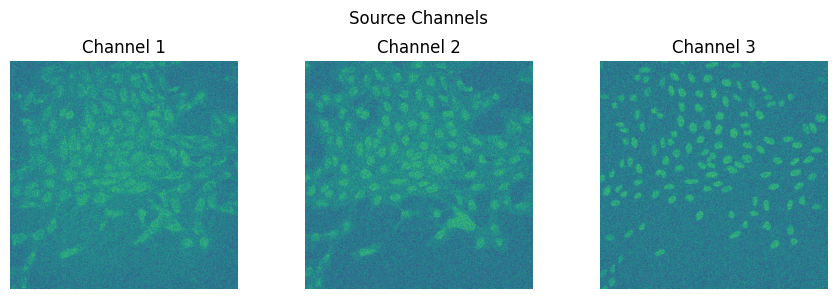

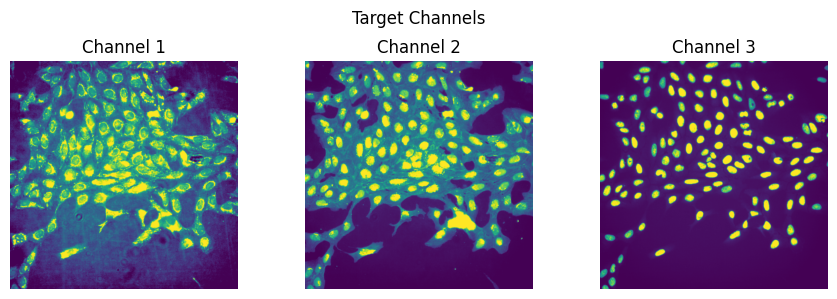

In [4]:

from data_loader import DiffusionDataset, get_diffusion_dataloader, visualize_image_channels

# 1) Point to the CSV that lists your partial paths for the dummy data:
csv_list = [os.path.join('..', "tests", "sdfsd_dummy data.csv")]

# 2) Create the dataset (channels 1–3 as “source”, 4–6 as “target”):
dataset = DiffusionDataset(
    csv_file_list=csv_list,
    images_dir=os.path.join('..', "tests",),
    source_channels=[6, 7, 8],
    target_channels=[1, 2, 5],
    img_size=(512,512)
)

# 3) Pull out one sample:
src_tensor, tgt_tensor = dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")


In [ ]:


source_channels = [6, 7, 8]
target_channels = [1, 2, 5]
num_workers = min(os.cpu_count() - 2, os.cpu_count() // 2)


# 1) Point to the CSV that lists your partial paths for the dummy data:
train_plates = ["BR00116991", "BR00116992", "BR00116995", "BR00117024"]
valid_plates = ["BR00116993", "BR00117025"]
test_plates = ["BR00116994", "BR00117026", "BR00118041", "BR00118045"]

train_plates = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in train_plates]
valid_plates = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in valid_plates]
test_plates  = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in test_plates]

train_dataset = DiffusionDataset(csv_file_list=train_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))
valid_dataset = DiffusionDataset(csv_file_list=valid_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))
test_dataset = DiffusionDataset(csv_file_list=test_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))

# data loader
train_loader = get_diffusion_dataloader(train_dataset, batch_size=2, num_workers=num_workers, shuffle=True)
valid_loader = get_diffusion_dataloader(valid_dataset, batch_size=2, num_workers=num_workers, shuffle=False)
test_loader = get_diffusion_dataloader(test_dataset, batch_size=2, num_workers=num_workers, shuffle=False)

# 3) Pull out one sample:
src_tensor, tgt_tensor = train_dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")

# config = CFG(kappa=2.0, p=0.5, eta_T=0.999, T=50)
# scheduler = DiffusionScheduler(config)
# result = scheduler.get_noisy_image(20, src_tensor, tgt_tensor)
# visualize_image_channels(result)




In [2]:
import torch
import os, sys

sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'models'))
from unet import UNetModelSwin


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


c:\Users\yuche\OneDrive\Documents\Brain in a vat\CAM Mphil\DIS_final_project\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
swin_unet_model = UNetModelSwin(image_size=256, 
              in_channels=3, model_channels=128, out_channels=3, 
              num_res_blocks=2, attention_resolutions=(128, 64), cond_lq = False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

swin_unet_model.to(device)

image = torch.randn(2, 3, 256, 256).to(device)
timesteps = torch.randint(0, 50, (2,)).to(device)

result = swin_unet_model(image, timesteps)


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


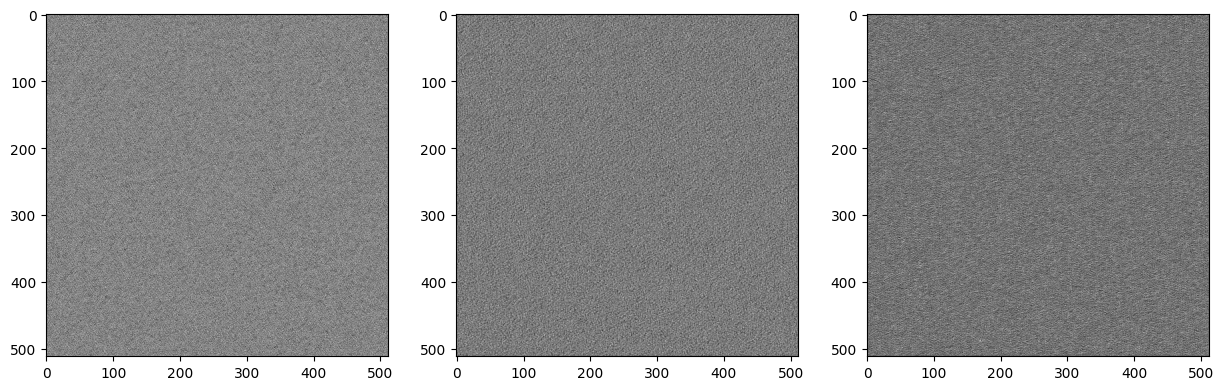

In [3]:
result = result.cpu().detach()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(result[0, 0, :, :], cmap="gray")
ax[1].imshow(result[0, 1, :, :], cmap="gray")
ax[2].imshow(result[0, 2, :, :], cmap="gray")

plt.show()
